## LIBS

In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,silhouette_score
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import tensorflow as tf
from keras.models import *
from keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping

import joblib

sns.set_style(style='darkgrid')
import warnings
warnings.filterwarnings('ignore')

## Read Data

In [2]:
df=pd.read_excel(r'Online Retail.xlsx')

## EDA & PreProcessing

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [5]:
df.sample(n=5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
24808,538349,84279P,CHERRY BLOSSOM DECORATIVE FLASK,1,2010-12-10 14:59:00,8.47,NaN,United Kingdom
54438,540953,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,1,2011-01-12 13:16:00,3.75,14587.0,United Kingdom
153650,C549783,22649,STRAWBERRY FAIRY CAKE TEAPOT,-1,2011-04-12 11:50:00,4.95,16558.0,United Kingdom
425833,573339,23158,SET OF 5 LUCKY CAT MAGNETS,12,2011-10-30 11:49:00,2.08,13278.0,United Kingdom
531778,C580966,23212,HEART WREATH DECORATION WITH BELL,-12,2011-12-06 14:52:00,1.25,16554.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


### Overview On The Dataset 

In [8]:
# Data Quality Check
print(f'Number of rows = {df.shape[0]}')
print(f'Number of Columns = {df.shape[1]}\n')

# Missing CustomerID
print('Count of missing CustomerID',df['CustomerID'].isna().sum())
print('Percentage of missing CustomerID',round(df['CustomerID'].isna().sum()/len(df)*100,2),'%')
print('Unique customers (non-null CustomerID):', df['CustomerID'].dropna().nunique(),'\n')
# Date Range
print(f'First InvoiceDate =', df['InvoiceDate'].min())
print(f'Last InvoiceDate =', df['InvoiceDate'].max(),'\n')

# Cancelled invoices (InvoiceNo starts with "C")
cancelled_rows = df['InvoiceNo'].astype(str).str.startswith('C')
print('Cancelled rows (InvoiceNo starts with "C"):', cancelled_rows.sum(), '\n')

# Invalid Rows
print('UnitPrice <= 0 rows:',len(df[df['UnitPrice']<=0]),'\n')
print('Quantity <= 0 rows:',len(df[df['Quantity']<=0]),'\n')


Number of rows = 541909
Number of Columns = 8

Count of missing CustomerID 135080
Percentage of missing CustomerID 24.93 %
Unique customers (non-null CustomerID): 4372 

First InvoiceDate = 2010-12-01 08:26:00
Last InvoiceDate = 2011-12-09 12:50:00 

Cancelled rows (InvoiceNo starts with "C"): 9288 

UnitPrice <= 0 rows: 2517 

Quantity <= 0 rows: 10624 



In [9]:
invalid_df=df[(df['CustomerID'].isna())|(df['Quantity']<=0)|(df['UnitPrice']<=0)|(df['InvoiceNo'].astype(str).str.startswith('C'))]

In [10]:
df_clean=df.drop(invalid_df.index)

In [11]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
# Data Quality Check
print(f'Number of rows = {df_clean.shape[0]}')
print(f'Number of Columns = {df_clean.shape[1]}\n')

# Missing CustomerID
print('Count of missing CustomerID',df_clean['CustomerID'].isna().sum())
print('Percentage of missing CustomerID',round(df_clean['CustomerID'].isna().sum()/len(df_clean)*100,2),'%')
print('Unique customers (non-null CustomerID):', df_clean['CustomerID'].dropna().nunique(),'\n')
# Date Range
print(f'First InvoiceDate =', df_clean['InvoiceDate'].min())
print(f'Last InvoiceDate =', df_clean['InvoiceDate'].max(),'\n')

# Cancelled invoices (InvoiceNo starts with "C")
cancelled_rows = df_clean['InvoiceNo'].astype(str).str.startswith('C')
print('Cancelled rows (InvoiceNo starts with "C"):', cancelled_rows.sum(), '\n')

# Invalid Rows
print('UnitPrice <= 0 rows:',len(df_clean[df_clean['UnitPrice']<=0]),'\n')
print('Quantity <= 0 rows:',len(df_clean[df_clean['Quantity']<=0]),'\n')


Number of rows = 397884
Number of Columns = 8

Count of missing CustomerID 0
Percentage of missing CustomerID 0.0 %
Unique customers (non-null CustomerID): 4338 

First InvoiceDate = 2010-12-01 08:26:00
Last InvoiceDate = 2011-12-09 12:50:00 

Cancelled rows (InvoiceNo starts with "C"): 0 

UnitPrice <= 0 rows: 0 

Quantity <= 0 rows: 0 



In [13]:
df_feat=df_clean.copy()

#### Handle Duplicates

In [14]:
print('Number of duplictes Before Handling =',df_feat.duplicated().sum())
df_feat.drop_duplicates(inplace=True)
print('Number of duplictes After Handling =',df_feat.duplicated().sum())

Number of duplictes Before Handling = 5192
Number of duplictes After Handling = 0


#### Calculating The Total Price

In [15]:
df_feat['Total_price']=df_feat['Quantity']*df_feat['UnitPrice']

In [16]:
df_feat.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [17]:
df_feat[df_feat['Total_price']<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price


#### Calculating (Day , Month,Year, Season)

In [18]:
df_feat['Time']=df_feat['InvoiceDate'].dt.time
df_feat['Day']=df_feat['InvoiceDate'].dt.day
df_feat['Month']=df_feat['InvoiceDate'].dt.month
df_feat['Year']=df_feat['InvoiceDate'].dt.year


In [19]:
conditions = [
    df_feat['Month'].isin([12, 1, 2]),
    df_feat['Month'].isin([3, 4, 5]),
    df_feat['Month'].isin([6, 7, 8]),
    df_feat['Month'].isin([9, 10, 11])
]

choices = ['winter', 'spring', 'summer', 'autumn']

df_feat['Season'] = np.select(conditions, choices,default='unknown')


In [20]:
df_feat.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price,Time,Day,Month,Year,Season
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,08:26:00,1,12,2010,winter
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,08:26:00,1,12,2010,winter
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,08:26:00,1,12,2010,winter
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,08:26:00,1,12,2010,winter
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,08:26:00,1,12,2010,winter


In [21]:
snapshot_date = df_feat['InvoiceDate'].max() + pd.Timedelta(days=1)
customer_df = df_feat.groupby('CustomerID').agg({
    'InvoiceDate': 'max',
    'InvoiceNo': 'nunique',
    'Total_price': 'sum'
})


In [22]:
customer_df.head()

,InvoiceDate,InvoiceNo,Total_price
CustomerID,,,
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,7,4310.00
12348.0,2011-09-25 13:13:00,4,1797.24
12349.0,2011-11-21 09:51:00,1,1757.55
12350.0,2011-02-02 16:01:00,1,334.40


In [23]:
customer_df['Recency']=(snapshot_date - customer_df['InvoiceDate']).dt.days


In [24]:
customer_df.head()

,InvoiceDate,InvoiceNo,Total_price,Recency
CustomerID,,,,
12346.0,2011-01-18 10:01:00,1,77183.60,326
12347.0,2011-12-07 15:52:00,7,4310.00,2
12348.0,2011-09-25 13:13:00,4,1797.24,75
12349.0,2011-11-21 09:51:00,1,1757.55,19
12350.0,2011-02-02 16:01:00,1,334.40,310


In [25]:
customer_df.rename( columns=
    {
        'InvoiceNo':'Frequency',
        'Total_price':'Monetary'
     },
     inplace=True

)
customer_df.drop('InvoiceDate',axis=1,inplace=True)
customer_df['CLV']=customer_df['Monetary']

In [26]:
customer_df.head()

,Frequency,Monetary,Recency,CLV
CustomerID,,,,
12346.0,1,77183.60,326,77183.60
12347.0,7,4310.00,2,4310.00
12348.0,4,1797.24,75,1797.24
12349.0,1,1757.55,19,1757.55
12350.0,1,334.40,310,334.40


0


<Axes: ylabel='CustomerID'>

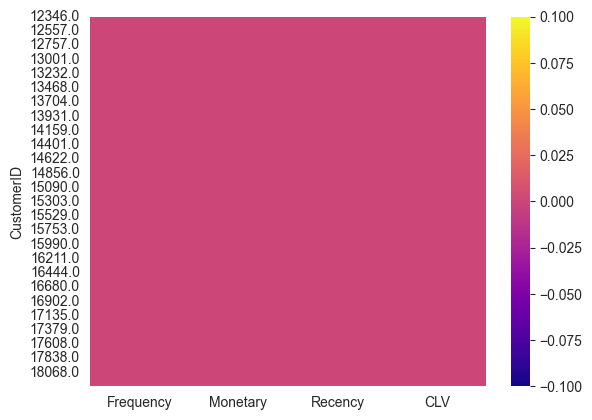

In [27]:
print(customer_df.isna().sum().sum())
sns.heatmap(customer_df.isna(),cmap='plasma')

In [28]:
customer_df.duplicated().sum()

np.int64(0)

In [29]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Frequency  4338 non-null   int64  
 1   Monetary   4338 non-null   float64
 2   Recency    4338 non-null   int64  
 3   CLV        4338 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 169.5 KB


In [30]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Frequency,4338.0,4.272015,7.697998,1.00,1.0000,2.00,5.0000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02
Recency,4338.0,92.536422,100.014169,1.00,18.0000,51.00,142.0000,374.00
CLV,4338.0,2048.688081,8985.230220,3.75,306.4825,668.57,1660.5975,280206.02


In [31]:
customer_df.groupby('CLV').sum().tail()

,Frequency,Monetary,Recency
CLV,,,
143711.17,201,143711.17,1
168472.50,2,168472.50,1
194390.79,46,194390.79,8
259657.30,60,259657.30,1
280206.02,73,280206.02,2


### Visualization

#### Time-series analysis of sales trends across 2010-2011

In [32]:
# 1️⃣ Unique customers per country
customers_by_country = (
    df_feat.groupby('Country')['CustomerID']
    .nunique()
    .sort_values(ascending=False)
)

print("Top 5 Countries by Customer Count:\n")
print(customers_by_country.head(), "\n")


# 2️⃣ Total revenue per country
revenue_by_country = (
    df_feat.groupby('Country')['Total_price']
    .sum()
    .sort_values(ascending=False)
)

print("Top 5 Countries by Revenue:\n")
print(revenue_by_country.head(), "\n")


# 3️⃣ UK Revenue Percentage
uk_revenue = revenue_by_country.loc['United Kingdom']
total_revenue = revenue_by_country.sum()

uk_percentage = (uk_revenue / total_revenue) * 100

print(f"UK Revenue Percentage: {uk_percentage:.2f}%")


Top 5 Countries by Customer Count:

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Name: CustomerID, dtype: int64 

Top 5 Countries by Revenue:

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: Total_price, dtype: float64 

UK Revenue Percentage: 81.97%


Most Customers per country Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Name: CustomerID, dtype: int64 



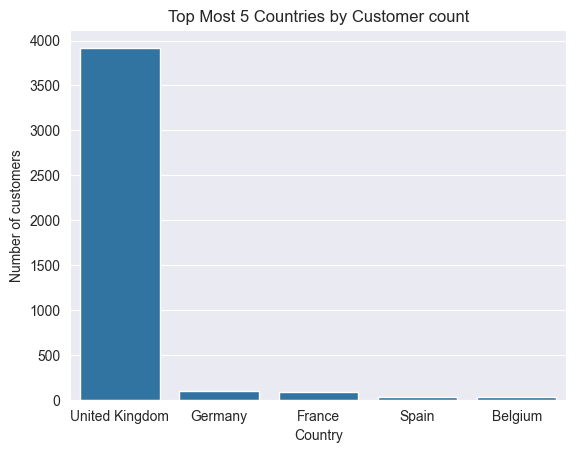

In [33]:
# Most Customers per country'
top_5_customers_countries=df_feat.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

print('Most Customers per country',top_5_customers_countries.head(),'\n')

plt.title('Top Most 5 Countries by Customer count')
sns.barplot(x=top_5_customers_countries.head().index,y=top_5_customers_countries.head().values)
plt.xlabel('Country')
plt.ylabel('Number of customers')
plt.show()

Most Revenues per country Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: Total_price, dtype: float64 



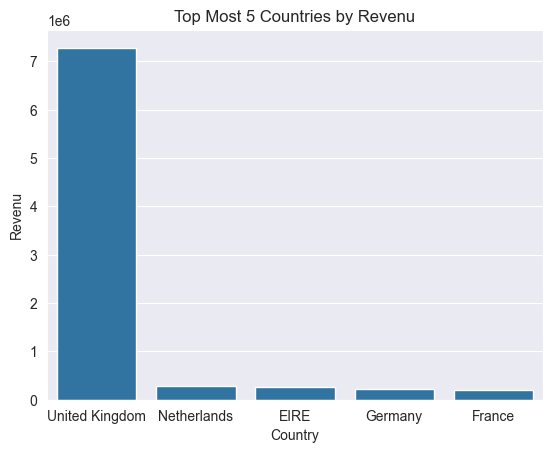

In [34]:
# Most revnue per country'
top_5_revnue_countries=df_feat.groupby('Country')['Total_price'].sum().sort_values(ascending=False)

print('Most Revenues per country',top_5_revnue_countries.head(),'\n')

plt.title('Top Most 5 Countries by Revenu')
sns.barplot(x=top_5_revnue_countries.head().index,y=top_5_revnue_countries.head().values)
plt.xlabel('Country')
plt.ylabel('Revenu')
plt.show()

YearMonth
2010-12    570422.730
2011-01    568101.310
2011-02    446084.920
2011-03    594081.760
2011-04    468374.331
Freq: M, Name: Total_price, dtype: float64


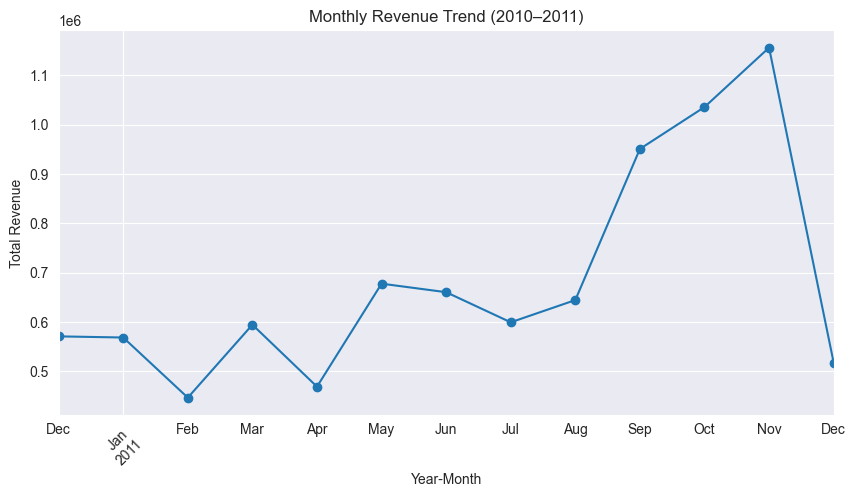

In [35]:
# Create Year-Month column
df_feat['YearMonth'] = df_feat['InvoiceDate'].dt.to_period('M')

# Monthly revenue
monthly_revenue = (
    df_feat.groupby('YearMonth')['Total_price']
    .sum()
    .sort_index()
)

print(monthly_revenue.head())

plt.figure(figsize=(10,5))
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend (2010–2011)')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()


#### Customer lifetime value distribution and Pareto analysis (80/20 rule)

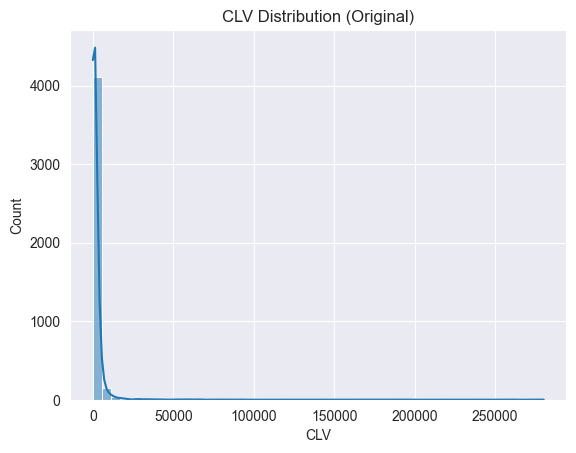

In [36]:
sns.histplot(customer_df['CLV'], bins=50,kde=True)
plt.title('CLV Distribution (Original)')
plt.show()


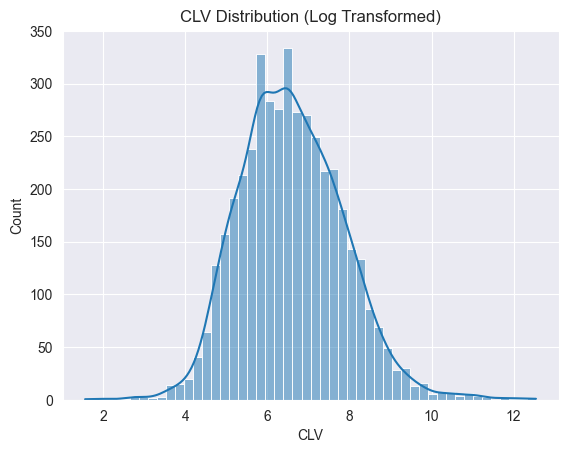

In [37]:
sns.histplot(np.log1p(customer_df['CLV']), bins=50,kde=True)
plt.title('CLV Distribution (Log Transformed)')
plt.show()


In [38]:
# Sort customers by CLV descending
pareto_df = customer_df.sort_values(by='CLV', ascending=False)

# Cumulative revenue
pareto_df['Cumulative_Revenue'] = pareto_df['CLV'].cumsum()

# Total revenue
total_revenue = pareto_df['CLV'].sum()

# Cumulative revenue percentage
pareto_df['Cumulative_Percentage'] = 100 * pareto_df['Cumulative_Revenue'] / total_revenue

# Find percentage of customers that generate 80% revenue
customers_80 = pareto_df[pareto_df['Cumulative_Percentage'] <= 80]
percentage_customers = len(customers_80) / len(pareto_df) * 100

print(f"Percentage of customers generating 80% of revenue: {percentage_customers:.2f}%")


Percentage of customers generating 80% of revenue: 26.03%


#### RFM feature distributions and correlations 

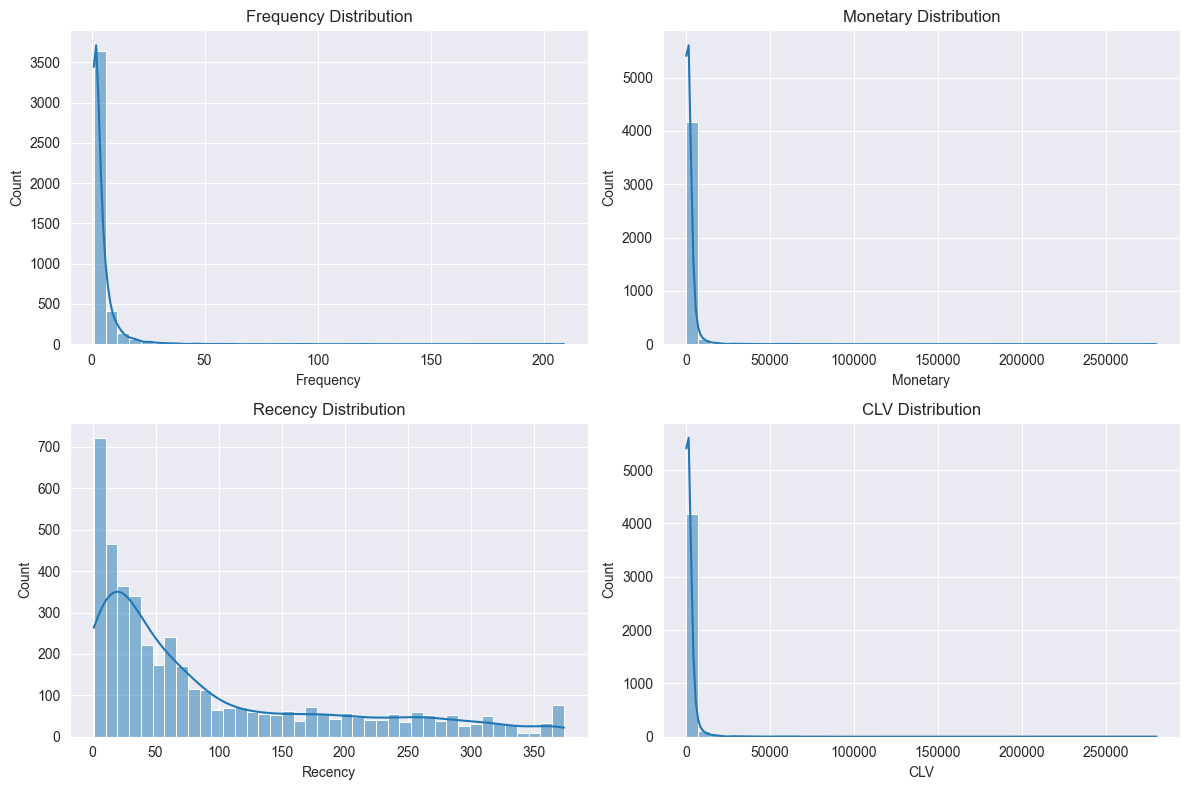

In [39]:
fig, axs = plt.subplots(2, 2, figsize=(12,8))

cols = customer_df.columns

for i, col in enumerate(cols):
    ax = axs[i//2, i%2]
    sns.histplot(customer_df[col], bins=40, ax=ax,kde=True)
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()


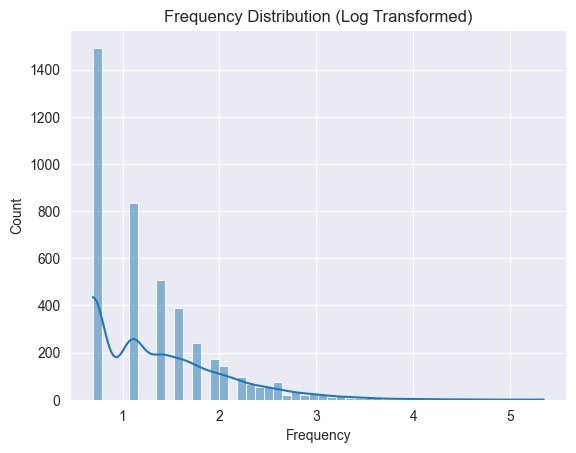

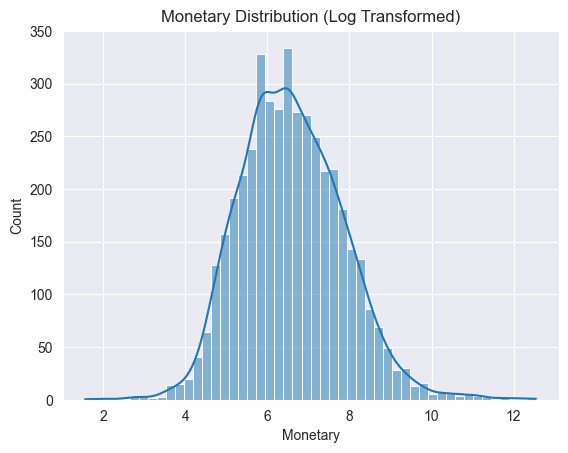

In [40]:
for col in ['Frequency','Monetary']:
    sns.histplot(np.log1p(customer_df[col]), bins=50,kde=True)
    plt.title(f'{col} Distribution (Log Transformed)')
    plt.show()

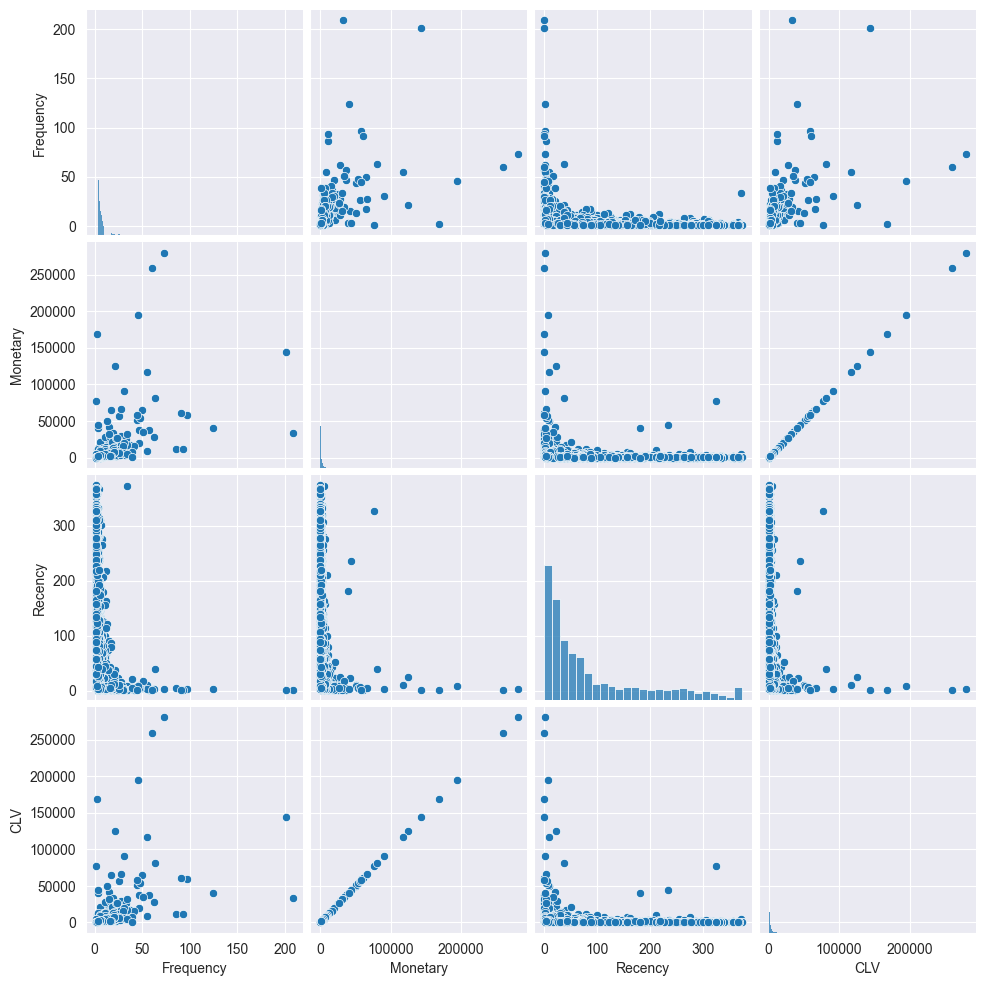

In [41]:
sns.pairplot(customer_df)

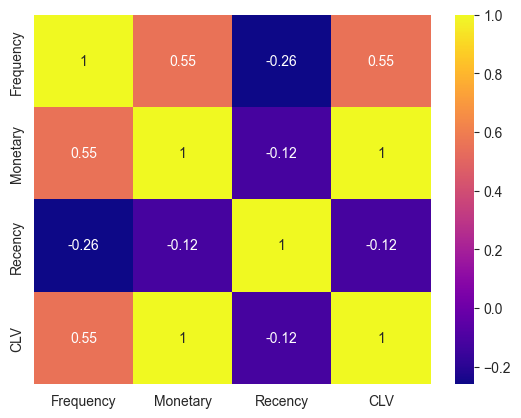

In [42]:
sns.heatmap(customer_df.corr(),cmap='plasma',annot=True)
plt.show()

#### Product popularity analysis using StockCode and Description

Top 10 Revenu Products
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Total_price, dtype: float64


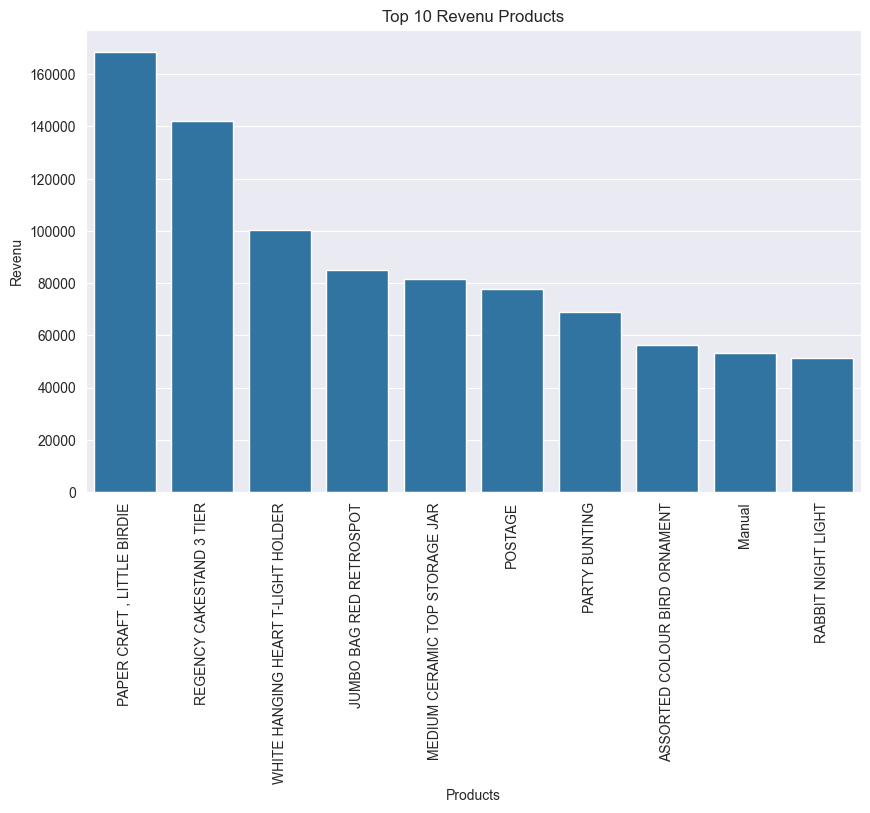

In [43]:
top_10_revenu_products=df_feat.groupby('Description')['Total_price'].sum().sort_values(ascending=False).head(10)
print('Top 10 Revenu Products')
print(top_10_revenu_products)
plt.figure(figsize=(10,6))
plt.title('Top 10 Revenu Products')
sns.barplot(top_10_revenu_products)
plt.xticks(rotation=90)
plt.xlabel('Products')
plt.ylabel('Revenu')
plt.show()

Top 10 Revenu StockCode
StockCode
23843     168469.60
22423     142264.75
85123A    100547.45
85099B     85040.54
23166      81416.73
POST       77803.96
47566      68785.23
84879      56413.03
M          53419.93
23084      51251.24
Name: Total_price, dtype: float64


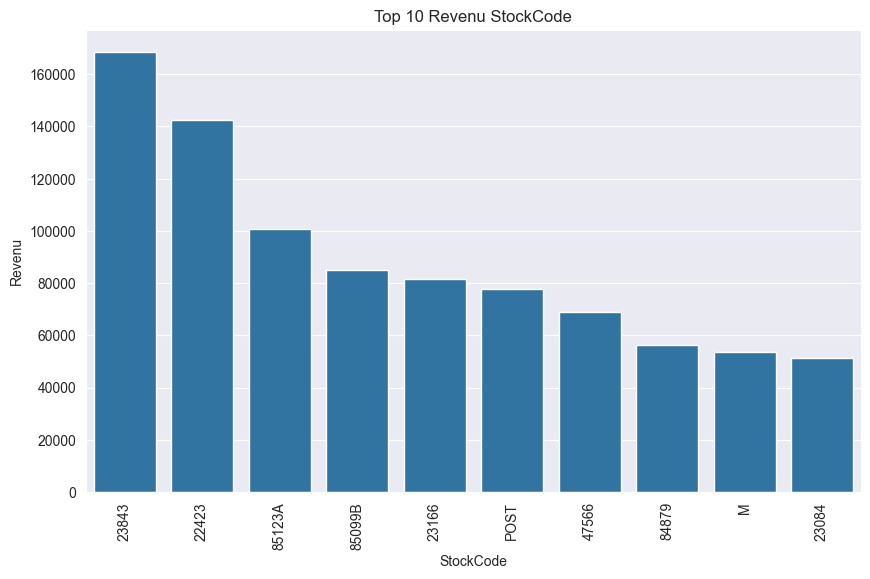

In [44]:
# Most StockCode revenu 
top_10_revenu_StockCode=df_feat.groupby('StockCode')['Total_price'].sum().sort_values(ascending=False).head(10)
print('Top 10 Revenu StockCode')
print(top_10_revenu_StockCode)
plt.figure(figsize=(10,6))
plt.title('Top 10 Revenu StockCode')
sns.barplot(top_10_revenu_StockCode)
plt.xticks(rotation=90)
plt.xlabel('StockCode')
plt.ylabel('Revenu')
plt.show()

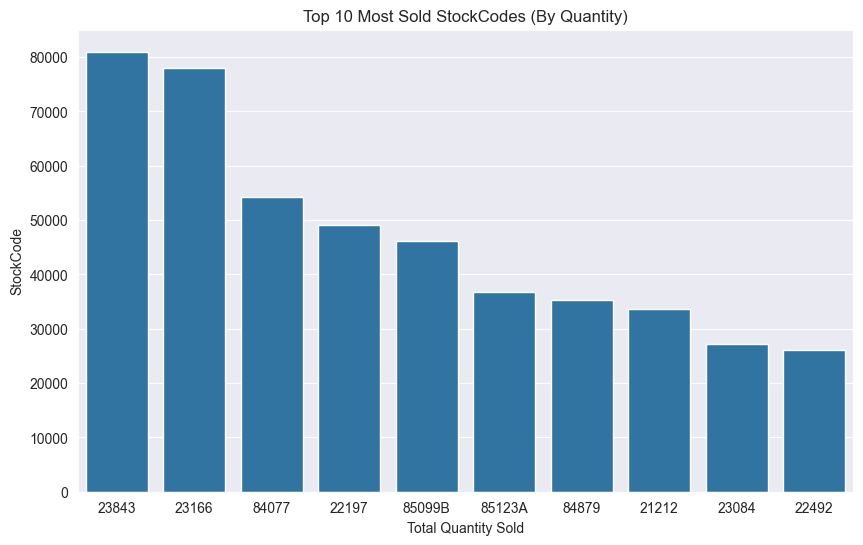

In [45]:
top_10_quantity_stockcode = (
    df_feat.groupby('StockCode')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    top_10_quantity_stockcode
)

plt.title('Top 10 Most Sold StockCodes (By Quantity)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('StockCode')
plt.show()


#### Cohort analysis to track customer retention over time 

In [46]:
df_feat['OrderMonth'] = df_feat['InvoiceDate'].dt.to_period('M')
df_feat['CohortMonth'] = (
    df_feat.groupby('CustomerID')['OrderMonth']
    .transform('min')
)


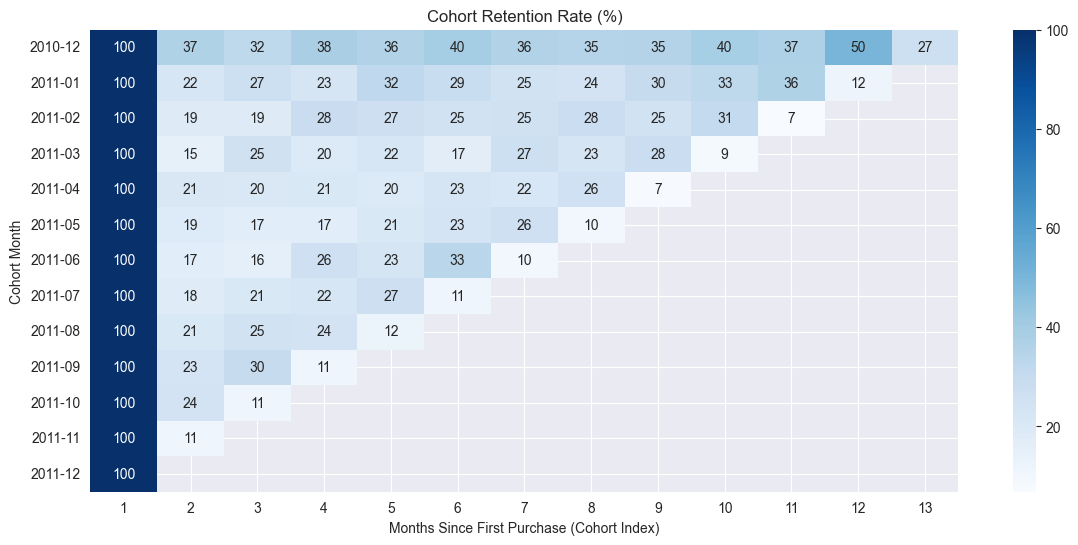

In [47]:
df_cohort = df_feat[['CustomerID', 'InvoiceDate']].copy()
df_cohort['OrderMonth'] = df_cohort['InvoiceDate'].dt.to_period('M')
df_cohort['CohortMonth'] = df_cohort.groupby('CustomerID')['OrderMonth'].transform('min')

order_y = df_cohort['OrderMonth'].dt.year
order_m = df_cohort['OrderMonth'].dt.month
cohort_y = df_cohort['CohortMonth'].dt.year
cohort_m = df_cohort['CohortMonth'].dt.month

df_cohort['CohortIndex'] = (order_y - cohort_y) * 12 + (order_m - cohort_m) + 1

cohort_counts = (
    df_cohort.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
    .nunique()
    .reset_index()
)


cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(14, 6))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="Blues")
plt.title("Cohort Retention Rate (%)")
plt.xlabel("Months Since First Purchase (Cohort Index)")
plt.ylabel("Cohort Month")
plt.show()


#### Seasonal patterns and peak purchasing periods

Seasons revenues
Season
autumn    3142538.262
winter    2101799.400
summer    1903059.991
spring    1739811.241
Name: Total_price, dtype: float64


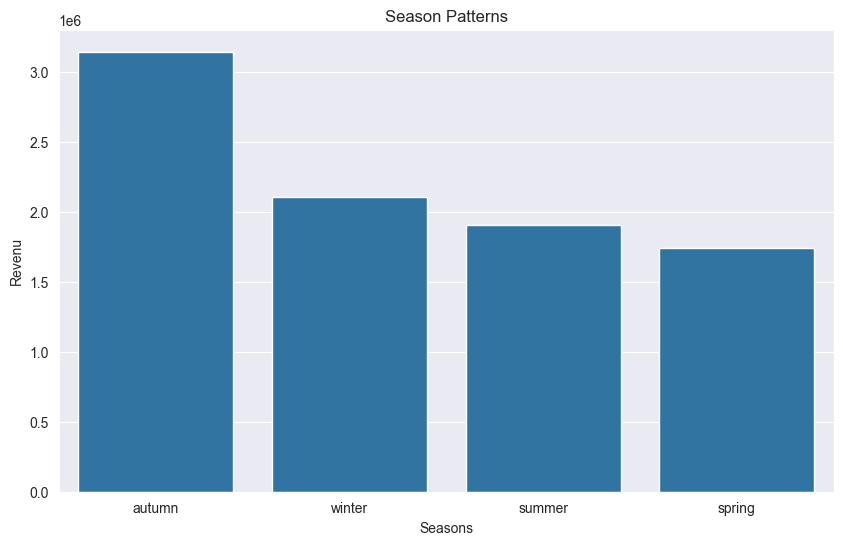

In [48]:
season_pattern_df=df_feat.groupby('Season')['Total_price'].sum().sort_values(ascending=False)
print('Seasons revenues')
print(season_pattern_df)

plt.figure(figsize=(10,6))
plt.title('Season Patterns')
sns.barplot(season_pattern_df)
plt.xlabel('Seasons')
plt.ylabel('Revenu')
plt.show()

#### Geographic analysis of customer spending patterns

Average Customer Spending by Country:

Country
EIRE           88420.820000
Netherlands    31716.260000
Singapore      21279.290000
Australia      15383.756667
Sweden          4795.978750
Japan           4677.046250
Iceland         4310.000000
Norway          3616.544000
Switzerland     2687.807143
Germany         2432.748936
Name: Total_price, dtype: float64


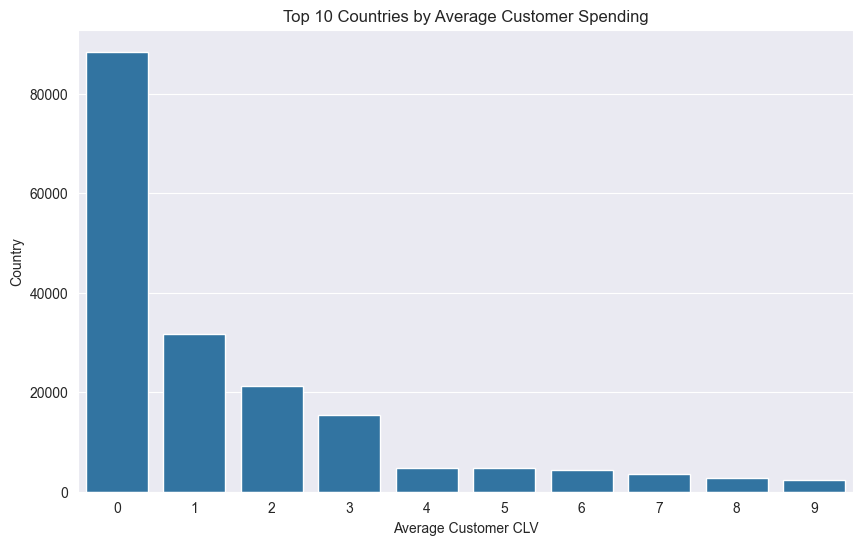

In [49]:
customer_country_revenue = (
    df_feat.groupby(['Country', 'CustomerID'])['Total_price']
    .sum()
    .reset_index()
)


avg_country_spending = (
    customer_country_revenue.groupby('Country')['Total_price']
    .mean()
    .sort_values(ascending=False)
)

print("Average Customer Spending by Country:\n")
print(avg_country_spending.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    avg_country_spending.head(10).values
)

plt.title('Top 10 Countries by Average Customer Spending')
plt.xlabel('Average Customer CLV')
plt.ylabel('Country')
plt.show()


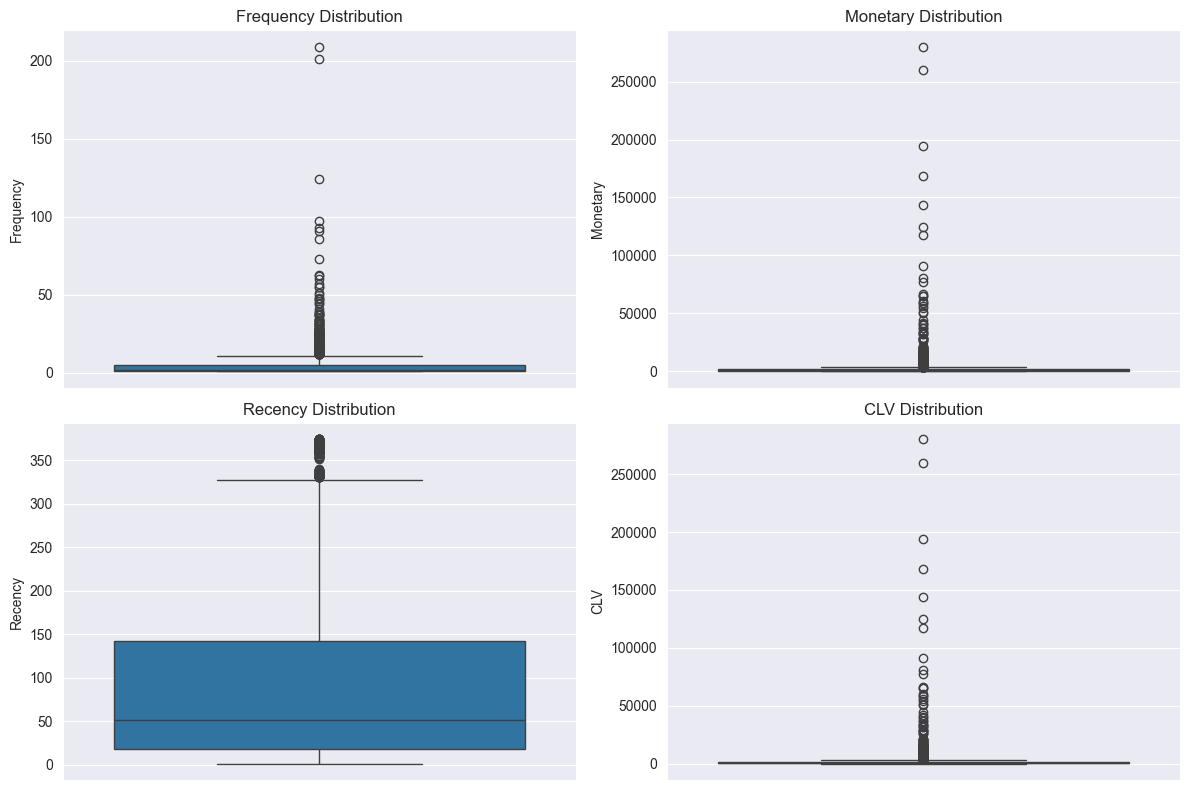

In [50]:
fig, axs = plt.subplots(2, 2, figsize=(12,8))

cols = customer_df.columns

for i, col in enumerate(cols):
    ax = axs[i//2, i%2]
    sns.boxplot(customer_df[col],ax=ax)
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

### Data Splitting

In [70]:
final_df=df_feat.copy()

In [71]:
cust_features = final_df.groupby('CustomerID').agg(
    unique_products=('Description', 'nunique'),
    total_items=('Quantity', 'sum'),
    avg_unitprice=('UnitPrice', 'mean'),
    max_unitprice=('UnitPrice', 'max'),
    most_common_country=('Country', lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
    most_common_season=('Season', lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
)

cust_features.head()


,unique_products,total_items,avg_unitprice,max_unitprice,most_common_country,most_common_season
CustomerID,,,,,,
12346.0,1,74215,1.040000,1.04,United Kingdom,winter
12347.0,103,2458,2.644011,12.75,Iceland,winter
12348.0,22,2341,5.764839,40.00,Finland,winter
12349.0,73,631,8.289041,300.00,Italy,autumn
12350.0,17,197,3.841176,40.00,Norway,winter


In [72]:
customer_df_merged = customer_df.merge(cust_features, left_index=True, right_index=True, how='left')
customer_df_merged.head()

,Frequency,Monetary,Recency,CLV,unique_products,total_items,avg_unitprice,max_unitprice,most_common_country,most_common_season
CustomerID,,,,,,,,,,
12346.0,1,77183.60,326,77183.60,1,74215,1.040000,1.04,United Kingdom,winter
12347.0,7,4310.00,2,4310.00,103,2458,2.644011,12.75,Iceland,winter
12348.0,4,1797.24,75,1797.24,22,2341,5.764839,40.00,Finland,winter
12349.0,1,1757.55,19,1757.55,73,631,8.289041,300.00,Italy,autumn
12350.0,1,334.40,310,334.40,17,197,3.841176,40.00,Norway,winter


In [73]:
X = customer_df_merged.drop(columns=['CLV', 'Monetary','Frequency'])

y = np.log10(customer_df_merged['CLV'])   ## We used Log Transformation cause CLV is too Skewed

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [269]:
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()


In [74]:
print(f'X_train Shape {X_train.shape}')
print(f'y_train Shape {y_train.shape}')
print(f'X_test Shape {X_test.shape}')
print(f'y_test Shape {y_test.shape}')

X_train Shape (3470, 7)
y_train Shape (3470,)
X_test Shape (868, 7)
y_test Shape (868,)


In [75]:
X_train.head()

,Recency,unique_products,total_items,avg_unitprice,max_unitprice,most_common_country,most_common_season
CustomerID,,,,,,,
12625.0,212,74,1612,2.171395,18.00,Germany,winter
13645.0,120,5,158,3.370000,9.95,United Kingdom,summer
15136.0,3,61,776,2.056176,4.95,United Kingdom,autumn
13731.0,219,36,278,4.289474,14.95,United Kingdom,spring
18156.0,13,100,283,2.956803,12.75,United Kingdom,autumn


In [123]:
num_cols=X.select_dtypes(include='number').columns
cat_cols = ['most_common_country', 'most_common_season']
print(num_cols)
print(cat_cols)

Index(['Recency', 'unique_products', 'total_items', 'avg_unitprice',
       'max_unitprice'],
      dtype='object')
['most_common_country', 'most_common_season']


#### Encoding

In [ ]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

test_ohe = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)


X_train = pd.concat([X_train[num_cols], train_ohe], axis=1)
X_test  = pd.concat([X_test[num_cols],  test_ohe], axis=1)


In [272]:
model_feature_columns = list(X_train.columns)
print("Model feature count:", len(model_feature_columns))


Model feature count: 45


#### Scaling

In [78]:
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

## Supervised ML

### Linear Regression

In [79]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_lr_pred=lr.predict(X_test)

In [88]:
print("Linear Regression Results")
print(f"MAE: {mean_absolute_error(y_test, y_lr_pred):.3f}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test, y_lr_pred)):.3f}", )
print(f"R2 Score:{r2_score(y_test, y_lr_pred):.3f}")

Linear Regression Results
MAE: 0.292
RMSE:0.382
R2 Score:0.521


### Random Forest

In [87]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42,criterion='squared_error')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}", )
print(f"R2 Score:{r2_score(y_test, y_pred_rf):.3f}")

Random Forest Results
MAE: 0.086
RMSE:0.119
R2 Score:0.953


### XGBOOST

In [85]:
param_grid = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_


Fitting 5 folds for each of 192 candidates, totalling 960 fits


In [86]:
y_pred_xgb = best_model.predict(X_test)

print("XGBoost Results")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.3f}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.3f}", )
print(f"R2 Score:{r2_score(y_test, y_pred_xgb):.3f}")

XGBoost Results
MAE: 0.078
RMSE:0.109
R2 Score:0.961


###  Feature importance analysis to identify key value drivers 

In [102]:
importances=best_model.feature_importances_
importance_df = pd.DataFrame(
    {
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)
importance_df.reset_index(drop=True,inplace=True)

In [103]:
importance_df.head(10)

,feature,importance
0,total_items,0.629400
1,unique_products,0.215453
2,avg_unitprice,0.053785
3,max_unitprice,0.024378
4,Recency,0.012799
5,most_common_country_Belgium,0.004973
6,most_common_country_United Kingdom,0.004158
7,most_common_country_Spain,0.003970
8,most_common_season_winter,0.003881
9,most_common_country_Sweden,0.003802


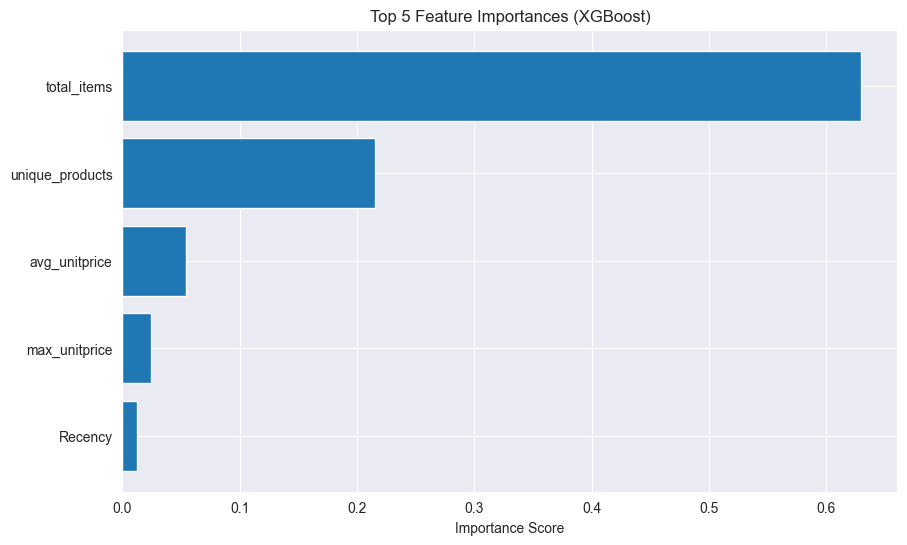

In [104]:
plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:5],
         importance_df['importance'][:5])
plt.gca().invert_yaxis()
plt.title("Top 5 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.show()


### Spearman Correlation

In [111]:
corr, p_value = spearmanr(y_test, y_pred_xgb)

print(f"Spearman Correlation: {corr:.3f}")


Spearman Correlation: 0.979


## Unsupervised ML 


### KMeans clustering

In [166]:
clustering_df=customer_df_merged[['Frequency', 'Monetary', 'Recency', 'CLV', 'unique_products','total_items', 'avg_unitprice']]
clustering_df.head()
scaler=StandardScaler()
clustering_df=pd.DataFrame(scaler.fit_transform(clustering_df),columns=clustering_df.columns)

In [167]:
scores={}
for k in range(3,11):
    k_mean_model=KMeans(k)
    k_mean_model.fit(clustering_df)
    scores[k]=k_mean_model.inertia_  # WCSS

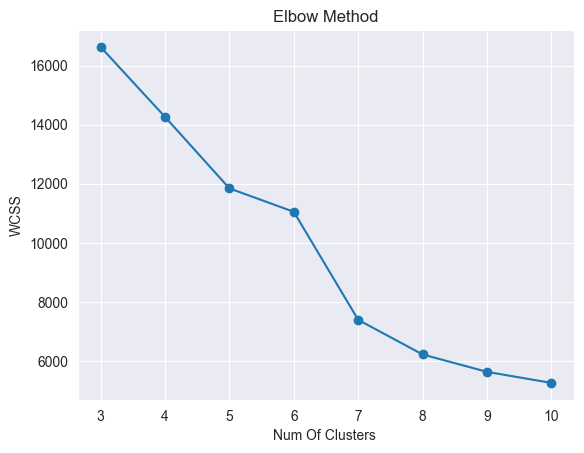

In [168]:
plt.plot(scores.keys(),scores.values(),marker='o')
plt.title('Elbow Method')
plt.xlabel('Num Of Clusters ')
plt.ylabel('WCSS')
plt.show()


### PCA for dimensionality reduction and cluster visualization 

### Silhouette Score

In [177]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
customer_df_merged['cluster'] = kmeans.fit_predict(clustering_df)


In [178]:
sil = silhouette_score(clustering_df, customer_df_merged['cluster'])
print("Final Silhouette Score:", sil)


Final Silhouette Score: 0.5048840705628697


### PCA for dimensionality reduction and cluster visualization 

In [182]:
k=5
pca=PCA(n_components=k)


In [183]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


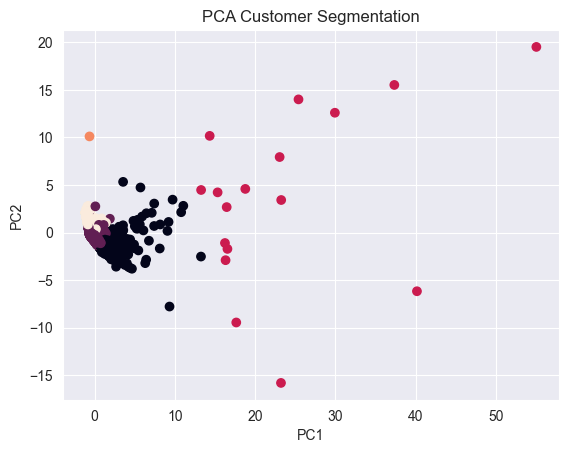

In [184]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(clustering_df)

plt.scatter(pca_components[:,0], pca_components[:,1],
            c=customer_df_merged['cluster'])
plt.title("PCA Customer Segmentation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Validate clusters using business metrics (average spend, purchase frequency, recency)

In [185]:
profile = customer_df_merged.groupby('cluster')[
    ['Recency','Frequency','Monetary',
     'unique_products','avg_unitprice']
].mean()

display(profile)


,Recency,Frequency,Monetary,unique_products,avg_unitprice
cluster,,,,,
0,17.145238,14.688095,7683.711643,210.304762,4.290827
1,46.094737,3.341053,1141.055285,50.667018,3.624491
2,25.764706,70.352941,112579.267647,603.411765,4.642714
3,85.000000,1.000000,2033.100000,1.000000,2033.100000
4,249.837143,1.565714,468.725515,24.092381,4.905187


### Customer Personas for each segment

In [ ]:
#Cluster 0: Loyal high-value customers with frequent purchases and strong spending behavior.

# Cluster 1: Occasional moderate spenders with low purchase frequency and medium engagement.

# Cluster 2: VIP / power buyers with extremely high frequency and monetary value.

# Cluster 3: High-ticket one-time buyers with a single large purchase and low repeat activity.

# Cluster 4: Dormant or at-risk customers with long inactivity and low overall spending.

## Deep Learning 


In [191]:
print(f'X_train Shape {X_train.shape}')
print(f'y_train Shape {y_train.shape}')
print(f'X_test Shape {X_test.shape}')
print(f'y_test Shape {y_test.shape}')

X_train Shape (3470, 45)
y_train Shape (3470,)
X_test Shape (868, 45)
y_test Shape (868,)


In [211]:
# DNN Model
n_feature=X_train.shape[1]
model=Sequential([
    # Input Layer
    Dense(128,input_shape=(n_feature,),activation='relu'),
    BatchNormalization(),
    Dropout(.3),

    Dense(64,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    Dense(32,activation='relu'),
    BatchNormalization(),
    # Dropout(.3),
    Dense(16,activation='relu'),
    BatchNormalization(),
    # Dropout(.3),
    Dense(1)

])
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,249 (67.38 KB)

 Non-trainable params: 480 (1.88 KB)

In [212]:
model.compile(optimizer='adam',loss='mse',metrics=[tf.keras.metrics.RootMeanSquaredError()])

In [213]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,              # wait 5 epochs without improvement
    restore_best_weights=True
)

In [214]:
history=model.fit(X_train,y_train,epochs=100,batch_size=64,validation_split=.2)

Epoch 1/100


44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 8.3533 - root_mean_squared_error: 2.8902 - val_loss: 6.7843 - val_root_mean_squared_error: 2.6047
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5554 - root_mean_squared_error: 2.5604 - val_loss: 5.0502 - val_root_mean_squared_error: 2.2473
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0456 - root_mean_squared_error: 2.2462 - val_loss: 3.5465 - val_root_mean_squared_error: 1.8832
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4400 - root_mean_squared_error: 1.8547 - val_loss: 2.0572 - val_root_mean_squared_error: 1.4343
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0127 - root_mean_squared_error: 1.4187 - val_loss: 0.9549 - val_root_mean_squared_error: 0.9772
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0225 - root_mean_squared_error: 1.0112 - val_loss: 0.3852 - val_root_mean_squared_error: 0.6206
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4784 - r

In [215]:
model.evaluate(X_test,y_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0479 - root_mean_squared_error: 0.2189 


[0.047900404781103134, 0.21886160969734192]

In [219]:
y_pred_dnn = model.predict(X_test).flatten()
r2_dnn = r2_score(y_test, y_pred_dnn)

print(f"DNN R2: {r2_dnn:.3f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
DNN R2: 0.843


### Compare deep learning performance against traditional ensemble methods

In [229]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Deep Neural Network"
    ],
    "RMSE (log scale)": [0.382, 0.119, 0.109, 0.219],
    "R² Score": [0.521, 0.953, 0.961, 0.843]
})

# Rank models
results["RMSE Rank"] = results["RMSE (log scale)"].rank()
results["R² Rank"] = results["R² Score"].rank(ascending=False)

# Styling
styled = (
    results.style
    .format({
        "RMSE (log scale)": "{:.3f}",
        "R² Score": "{:.3f}"
    })
    .highlight_min(subset=["RMSE (log scale)"], color="blue")
    .highlight_max(subset=["R² Score"], color="blue")
    .set_properties(**{"text-align": "center"})
)

styled


,Model,RMSE (log scale),R² Score,RMSE Rank,R² Rank
0,Linear Regression,0.382,0.521,4.000000,4.000000
1,Random Forest,0.119,0.953,2.000000,2.000000
2,XGBoost,0.109,0.961,1.000000,1.000000
3,Deep Neural Network,0.219,0.843,3.000000,3.000000


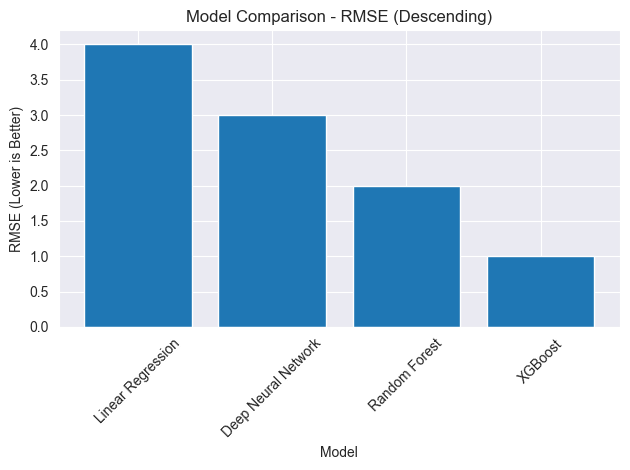

In [231]:
# Sort RMSE descending
rmse_sorted = results.sort_values("RMSE Rank", ascending=False)
plt.figure()
plt.bar(rmse_sorted["Model"], rmse_sorted["RMSE Rank"])
plt.xticks(rotation=45)
plt.title("Model Comparison - RMSE (Descending)")
plt.ylabel("RMSE (Lower is Better)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


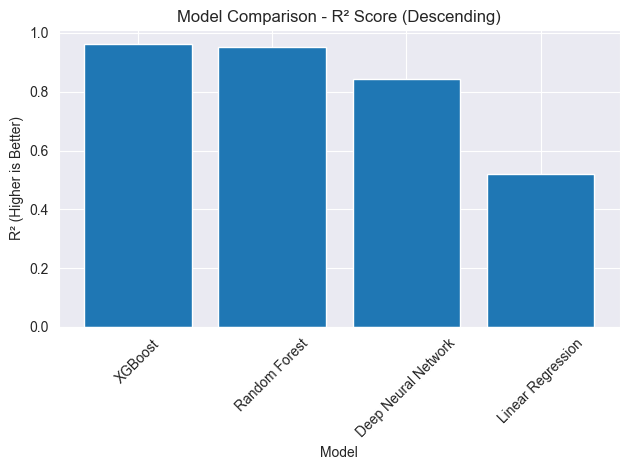

In [230]:
# Sort R2 descending
r2_sorted = results.sort_values("R² Score", ascending=False)

plt.figure()
plt.bar(r2_sorted["Model"], r2_sorted["R² Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison - R² Score (Descending)")
plt.ylabel("R² (Higher is Better)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


### Implement Autoencoders

In [236]:
latent_dim=8

# Encoder
inputs=Input(shape=(n_feature,))
x=Dense(32,activation='relu')(inputs)
x=BatchNormalization()(x)
x=Dropout(.3)(x)

x=Dense(16,activation='relu')(x)
x=BatchNormalization()(x)
x=Dropout(.3)(x)

latent=Dense(latent_dim,activation='relu',name='Latent')(x)

# Decoder

x=Dense(16,activation='relu')(latent)
x=BatchNormalization()(x)
x=Dropout(.3)(x)

x=Dense(32,activation='relu')(x)
x=BatchNormalization()(x)
x=Dropout(.3)(x)

outputs=Dense(n_feature,activation='linear')(x)





In [237]:
autoencoder=Model(inputs,outputs,name='autoencoder') # full network X → X'
encoder=Model(inputs,latent,name='encoder')          # X → Z (latent features)


In [238]:
autoencoder.compile(optimizer='adam',loss='mse',metrics=[tf.keras.metrics.RootMeanSquaredError()])
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [240]:
auto_encoder_history=autoencoder.fit(
    X_train, X_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.0234 - root_mean_squared_error: 1.0117 - val_loss: 0.0949 - val_root_mean_squared_error: 0.3081
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6262 - root_mean_squared_error: 0.7913 - val_loss: 0.0888 - val_root_mean_squared_error: 0.2980
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4470 - root_mean_squared_error: 0.6686 - val_loss: 0.0839 - val_root_mean_squared_error: 0.2897
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3496 - root_mean_squared_error: 0.5912 - val_loss: 0.0767 - val_root_mean_squared_error: 0.2770
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2917 - root_mean_squared_error: 0.5401 - val_loss: 0.0705 - val_root_mean_squared_error: 0.2655
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2586 - root_mean_squared_error: 0.5085 - val_loss: 0.0650 - val_root_mean_squared_error: 0.2550
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss

In [246]:
loss_mse, rmse = autoencoder.evaluate(X_test, X_test, verbose=0)
print(f"Autoencoder Test MSE:  {loss_mse:.4f}")
print(f"Autoencoder Test RMSE: {rmse:.4f}")


Autoencoder Test MSE:  0.0883
Autoencoder Test RMSE: 0.2972


In [249]:
Z_train = encoder.predict(X_train, verbose=0)
Z_test  = encoder.predict(X_test, verbose=0)

print("Z_train shape:", Z_train.shape)
print("Z_test shape :", Z_test.shape)


Z_train shape: (3470, 8)
Z_test shape : (868, 8)


### Latent + PCA

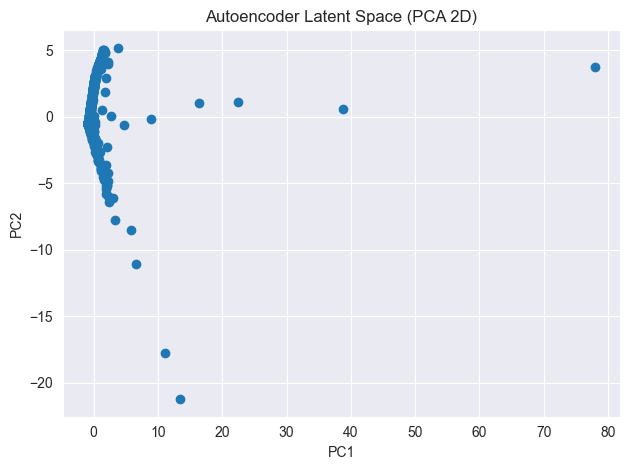

In [250]:
Z_2d = PCA(n_components=2, random_state=42).fit_transform(Z_test)
plt.figure()
plt.scatter(Z_2d[:,0], Z_2d[:,1])
plt.title("Autoencoder Latent Space (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


### latent→CLV model 

In [253]:
rf_latent = RandomForestRegressor(n_estimators=200, random_state=42)
rf_latent.fit(Z_train, y_train)

pred = rf_latent.predict(Z_test)

rmse_latent = np.sqrt(mean_squared_error(y_test, pred))
r2_latent = r2_score(y_test, pred)

print("RF on Latent -> RMSE:", round(rmse_latent, 3))
print("RF on Latent -> R2  :", round(r2_latent, 3))


RF on Latent -> RMSE: 0.327
RF on Latent -> R2  : 0.649


## preparing To Deployment

In [258]:
final_model=best_model
final_scaler=scaler

In [279]:
from sklearn.preprocessing import StandardScaler

# Make sure X_train here is the encoded dataframe with 45 columns (same used for model)
num_scaler = StandardScaler()
num_scaler.fit(X_train[num_cols])   # numeric cols only

print("num_scaler fitted on:", num_cols)


num_scaler fitted on: Index(['Recency', 'unique_products', 'total_items', 'avg_unitprice',
       'max_unitprice'],
      dtype='object')


In [280]:
import pandas as pd
import numpy as np

# model_feature_columns: list of 45 columns (already created)
# num_cols: list of numeric cols
# scaler: fitted scaler (on num_cols)
# best_model: trained model

LOG_MODE = "log10"  # you used np.log10

def build_encoded_row(recency, unique_products, total_items,
                      avg_unitprice, max_unitprice,
                      country, season):
    # Start with zeros for all model features
    row = pd.DataFrame([0]*len(model_feature_columns)).T
    row.columns = model_feature_columns
    
    # Fill numeric
    row.loc[0, "Recency"] = recency
    row.loc[0, "unique_products"] = unique_products
    row.loc[0, "total_items"] = total_items
    row.loc[0, "avg_unitprice"] = avg_unitprice
    row.loc[0, "max_unitprice"] = max_unitprice
    
    # Set one-hot for country if column exists
    country_col = f"most_common_country_{country}"
    if country_col in row.columns:
        row.loc[0, country_col] = 1
    
    # Set one-hot for season if column exists
    season_col = f"most_common_season_{season}"
    if season_col in row.columns:
        row.loc[0, season_col] = 1
    
    # Scale numeric columns only
    row[num_cols] = num_scaler.transform(row[num_cols])
    
    return row

def predict_clv_manual(recency, unique_products, total_items,
                       avg_unitprice, max_unitprice,
                       country, season):
    X_ready = build_encoded_row(recency, unique_products, total_items,
                                avg_unitprice, max_unitprice,
                                country, season)

    y_log = float(best_model.predict(X_ready)[0])
    y_clv = float(10 ** y_log)  # inverse log10
    return y_log, y_clv


In [281]:
log_pred, clv_pred = predict_clv_manual(
    recency=30,
    unique_products=10,
    total_items=200,
    avg_unitprice=3.5,
    max_unitprice=15,
    country="United Kingdom",
    season="winter"
)

print("Pred log10(CLV):", log_pred)
print("Pred CLV:", clv_pred)


Pred log10(CLV): 5.227902889251709
Pred CLV: 169006.29815691506


In [282]:
import joblib

joblib.dump(best_model, "xgb_model.pkl")
joblib.dump(num_scaler, "num_scaler.pkl")
joblib.dump(model_feature_columns, "model_feature_columns.pkl")
joblib.dump(num_cols, "num_cols.pkl")

print("Saved: xgb_model.pkl, num_scaler.pkl, model_feature_columns.pkl, num_cols.pkl")


Saved: xgb_model.pkl, num_scaler.pkl, model_feature_columns.pkl, num_cols.pkl
